# Tuning Parameters: storage concurrency (MinIO) and CPU use

**MinIO.** `data/s3-grid.csv` comes from a microbenchmark (`pipeline/s3probe.yml.j2`: one scan of `lineitem`
reading 7 columns and writing almost nothing) run for every distinct split of the table (11 values of
`max_size_mb`, 580 → 70 functions) × `max_parallel` ∈ {10, 20, 30, 50, 70, 100}, 3 runs each. Per configuration:
functions `p`, MB per function, functions reading at once (`readers`, time-averaged), read time (median, p95),
per-function and aggregate throughput, scan wall time. `data/minio.json` is the fit of the aggregate throughput
A(k) = min(k·B₁, B_max / (1 + γk)).

**CPU.** `data/task-profile.csv`: per operator, the total time of all functions of the BLOOM-FaaS S3 runs
(285 runs) split into dispatch / input / compute / output demand, the CPU time used (`time.process_time()` of the
function process) and the vCPU-seconds allocated (vCPU × execution time).

In [1]:
import os, sys, json
sys.path.insert(0, os.path.abspath(".."))      # repository root: cofi/style.py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from cofi import style
%matplotlib inline
style.apply()
FONT_SIZE = style.FONT_SIZE
DATA, FIG = "data", "figures"
os.makedirs(FIG, exist_ok=True)
pd.set_option("display.width", 160)
qnum = lambda q: int("".join(c for c in q if c.isdigit()) or 0)

G = pd.read_csv(f"{DATA}/s3-grid.csv")
M = json.load(open(f"{DATA}/minio.json"))
TP = pd.read_csv(f"{DATA}/task-profile.csv").set_index("operator")
META = json.load(open(f"{DATA}/task-profile-meta.json"))
b1, bmax, g = M["B1_MBps"], M["Bmax_MBps"], M["gamma"]
agg = lambda k: np.minimum(k * b1, bmax / (1 + g * k))
k_star = (-1 + np.sqrt(1 + 4 * g * bmax / b1)) / (2 * g)
print(f"B1 = {b1:.0f} MB/s, Bmax = {bmax:.0f} MB/s, gamma = {g:.3f}, k* = {k_star:.1f}, peak = {agg(k_star) / 1024:.2f} GB/s, "
      f"error aggregate {M['mape_agg_%']:.0f}% / per function {M['mape_fn_%']:.0f}%")

B1 = 234 MB/s, Bmax = 2403 MB/s, gamma = 0.013, k* = 9.2, peak = 2.10 GB/s, error aggregate 4% / per function 9%


## MinIO aggregate read throughput vs. functions reading at once

findfont: Failed to find font weight normal for Apple Chancery, now using 0.


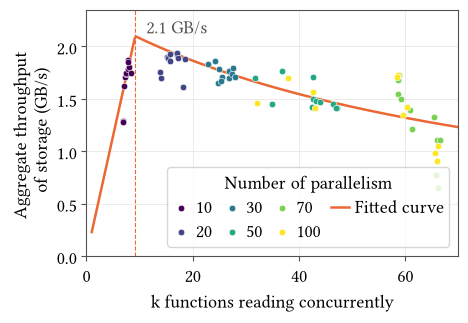

In [2]:
FIGSIZE, XMAX, YMAX = (4.8, 3.2), 70, 2.35
MODEL = "#eb6834"
mps = sorted(G["mp"].unique())
cmap = plt.get_cmap("viridis", len(mps))
fig, ax = plt.subplots(figsize=FIGSIZE)
for i, mp in enumerate(mps):
    R = G[G.mp == mp]
    ax.scatter(R["readers"], R["agg_MBps"] / 1024, s=22, color=cmap(i), edgecolor="white", lw=0.4, zorder=3, label=f"{int(mp)}")

k = np.linspace(1, XMAX, 300)
ax.plot(k, agg(k) / 1024, color=MODEL, lw=1.8, zorder=2, label="Fitted curve")
ax.axvline(k_star, color=MODEL, lw=0.8, ls="--", zorder=1)
# ax.annotate(f"$k^*$ ≈ {k_star:.0f}", (k_star, 0.15), xytext=(4, 0), textcoords="offset points", color=MODEL, fontsize=FONT_SIZE)
ax.annotate(f"{agg(k_star) / 1024:.1f} GB/s", (k_star, agg(k_star) / 1024), xytext=(8, 2), textcoords="offset points", color=style.INK2, fontsize=FONT_SIZE)
ax.set_xlim(0, XMAX); ax.set_ylim(0, YMAX)
ax.set_xlabel("$k$ functions reading concurrently")
ax.set_ylabel("Aggregate throughput \n of storage (GB/s)")
ax.grid(True, color=style.GRID); ax.set_axisbelow(True)
ax.legend(title="Number of parallelism", title_fontsize=FONT_SIZE, fontsize=FONT_SIZE, frameon=True, ncol=4, loc="lower right", borderpad=0.3, labelspacing=0.2, handlelength=1.0, handletextpad=0.3, columnspacing=0.6)

style.save(fig, FIG, "minio-g5k-agg")
plt.show()

## Scan time and billed read time per configuration

In [3]:
G["billed_read_s"] = G["p"] * G["t_read"]
t = G.pivot_table(index="size", columns="mp", values="wall").round(2)
b = G.pivot_table(index="size", columns="mp", values="billed_read_s").round(0)
print("lineitem scan wall time (s): rows = max_size_mb, columns = max_parallel"); display(t)
print("billed read time = functions × read time (s)"); display(b)

lineitem scan wall time (s): rows = max_size_mb, columns = max_parallel


mp,10,20,30,50,70,100
size,,,,,,
5,9.30,7.05,6.56,7.05,7.13,6.97
30,9.37,6.83,7.27,6.79,6.97,7.03
50,7.41,6.33,6.46,7.08,7.76,7.05
65,7.04,6.36,6.73,8.01,8.01,8.44
70,6.91,6.24,7.03,8.11,8.64,8.92
90,6.87,6.45,7.20,8.19,9.95,8.20
110,6.74,6.27,7.06,8.27,9.08,12.23
130,6.64,6.19,6.80,8.51,10.83,7.69
155,6.41,7.45,6.93,8.44,10.86,11.40


billed read time = functions × read time (s)


mp,10,20,30,50,70,100
size,,,,,,
5,57.0,94.0,140.0,306.0,382.0,381.0
30,56.0,88.0,186.0,235.0,362.0,391.0
50,48.0,90.0,147.0,219.0,407.0,255.0
65,48.0,92.0,149.0,323.0,409.0,435.0
70,46.0,90.0,170.0,323.0,408.0,407.0
90,47.0,91.0,171.0,322.0,457.0,233.0
110,51.0,101.0,187.0,367.0,483.0,481.0
130,50.0,101.0,180.0,358.0,509.0,299.0
155,47.0,117.0,172.0,317.0,548.0,518.0


## Where a function's time goes, per compute work operator

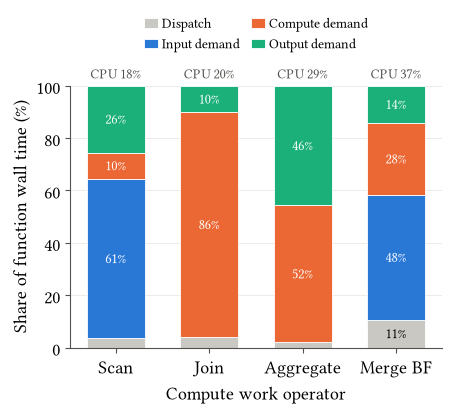

285 runs, 86604 function invocations, cold starts: 0


In [4]:
FIGSIZE = (4.8, 3.4)
ORDER = ["Scan", "Join", "Aggregate", "Merge BF"]
PARTS = [("dispatch_s", "Dispatch", "#c9c8c2"), ("input_s", "Input demand", "#2a78d6"),
         ("compute_s", "Compute demand", "#eb6834"), ("output_s", "Output demand", "#1baf7a")]
wall = TP["t_total_s"] + TP["dispatch_s"]
cpu = 100 * TP["cpu_s"] / TP["vcpu_s"]
fig, ax = plt.subplots(figsize=FIGSIZE)
bottom = np.zeros(len(ORDER))
for k, lab, col in PARTS:
    v = (100 * TP.loc[ORDER, k] / wall[ORDER]).to_numpy()
    ax.bar(range(len(ORDER)), v, bottom=bottom, color=col, edgecolor="white", lw=0.6, width=0.62, label=lab)
    for i, (b, h) in enumerate(zip(bottom, v)):
        if h >= 8:
            ax.text(i, b + h / 2, f"{h:.0f}%", ha="center", va="center", fontsize=FONT_SIZE - 3,
                    color="white" if col != "#c9c8c2" else "black")
    bottom += v
for i, e in enumerate(ORDER):
    ax.text(i, 101.5, f"CPU {cpu[e]:.0f}%", ha="center", va="bottom", fontsize=FONT_SIZE - 3, color=style.INK2)
ax.set_xticks(range(len(ORDER)), ORDER)
ax.set_xlabel("Compute work operator")
ax.set_ylim(0, 100); ax.set_ylabel("Share of function wall time (%)")
ax.grid(True, axis="y", color=style.GRID); ax.grid(False, axis="x"); ax.set_axisbelow(True)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.legend(ncol=2, loc="lower center", bbox_to_anchor=(0.5, 1.08), frameon=False, fontsize=FONT_SIZE - 3,
          handlelength=1.0, handletextpad=0.3, columnspacing=0.8, labelspacing=0.3)
style.save(fig, FIG, "task-profile-g5k")
plt.show()
print(f"{META['runs']} runs, {META['tasks']} function invocations, cold starts: {META['cold_starts']}")

In [5]:
tab = pd.DataFrame({lab: 100 * TP[k] / wall for k, lab, _ in PARTS})
tab["CPU used (% of vCPU)"] = cpu
tab["functions"] = TP["tasks"].astype(int)
tab.loc[ORDER].round(1)

,Dispatch,Input demand,Compute demand,Output demand,CPU used (% of vCPU),functions
operator,,,,,,
Scan,3.5,60.9,10.1,25.5,18.0,45645
Join,4.1,0.0,85.7,10.2,19.7,25163
Aggregate,2.0,0.0,52.3,45.7,28.5,15001
Merge BF,10.6,47.7,27.5,14.2,37.2,510


## System parameters

`data/system-params.csv`: the parameters of the testbed and of the cost model, each in its base unit (per function,
per vCPU, per request, ...), as configured (`deploy.yaml`, runner) or as calibrated on the 285 BLOOM-FaaS S3 runs
(v5 model) and fitted on the MinIO microbenchmark. LaTeX: `figures/system-params-table.tex`.

In [6]:
SP = pd.read_csv(f"{DATA}/system-params.csv")


def fmt_value(v):
    if v == 0:
        return "0"
    if abs(v) < 1e-3 or abs(v) >= 1e6:
        m, e = f"{v:.3e}".split("e")
        return f"{float(m):g}e{int(e)}"
    return f"{v:,.0f}" if float(v).is_integer() else f"{v:.4g}"


SP["value"] = SP["value"].map(fmt_value)
display(SP.set_index(["category", "parameter"])[["symbol", "value", "unit"]].fillna(""))

TEX_SYM = {"c": "$c$", "B1": "$B_1$", "Bmax": "$B_{max}$", "gamma": r"$\gamma$", "bw_s3": r"$bw^{s3}$",
           "beta_s3": r"$\beta^{s3}$", "bw_nfs": r"$bw^{nfs}$", "lat_nfs": r"$\kappa^{lat}_{nfs}$",
           "kappa_disp": r"$\kappa^{disp}$", "r_hash": r"$r^{hash}$", "max_parallel": r"(\texttt{max\_parallel})",
           "max_size_mb": r"(\texttt{max\_size\_mb})", "max_workers": r"(\texttt{max\_workers})"}
OP_SYM = {"Scan": "scan", "Join": "join", "Aggregate": "agg"}     # operator subscript of kappa_cpu, beta_cpu, kappa_qlat
tex_unit = lambda u: str(u).replace("$", r"\$").replace("%", r"\%")


def tex_symbol(r):
    if not isinstance(r.symbol, str):
        return ""
    if r.symbol in ("kappa_cpu", "beta_cpu", "kappa_qlat"):
        op = OP_SYM[r.parameter.split()[0]]
        base = {"kappa_cpu": r"\kappa^{cpu}", "beta_cpu": r"\beta^{cpu}", "kappa_qlat": r"\kappa^{qlat}"}[r.symbol]
        return f"${base}_{{{op}}}$"
    return TEX_SYM.get(r.symbol, "")


def tex_value(v):
    if "e" in v:
        m, e = v.split("e")
        return f"${m}\\times10^{{{int(e)}}}$"
    return v.replace(",", "")


# two columns: parameter (with its symbol) | value and unit
lines = [r"\begin{tabular}{lr}", r"\toprule", r"Parameter & Value \\"]
for cat, g in SP.groupby("category", sort=False):
    lines += [r"\midrule", rf"\multicolumn{{2}}{{l}}{{\textit{{{cat}}}}} \\"]
    for r in g.itertuples():
        sym = tex_symbol(r)
        lines.append(f"{r.parameter}{' ' + sym if sym else ''} & {tex_value(r.value)} {tex_unit(r.unit)} \\\\")
lines += [r"\bottomrule", r"\end{tabular}"]
open(f"{FIG}/system-params-table.tex", "w").write("\n".join(lines) + "\n")
print("\n".join(lines))

symbol     value             unit
category                parameter                                                                          
Function                vCPU per function                                      c         2             vCPU
                        Memory per function                                          2,048              MiB
                        Requests per instance                                            1          request
                        Function timeout                                               300                s
                        Minimum instances                                               30         instance
                        Maximum instances                                               70         instance
Runner                  Functions running at once per stage         max_parallel        70         function
                        Default partition size                       max_size_mb        50               MB
                        Reader threads per scan function             max_workers         4           thread
                        Retries per task                                                 3            retry
                        Rows per task (limit)                                        4.5e7              row
Storage (MinIO, fitted) Read bandwidth of one function alone                  B1     234.1             MB/s
                        Peak aggregate read bandwidth                       Bmax      2403             MB/s
                        Slowdown per concurrent reader                     gamma     0.013       1/function
Model (calibrated)      S3 bandwidth                                       bw_s3       147             MB/s
                        S3 slowdown per concurrent function              beta_s3    0.2744            ms/MB
                        NFS bandwidth                                     bw_nfs     784.1             MB/s
                        NFS latency                                      lat_nfs    0.9428       ms/request
                        Dispatch time                                 kappa_disp     46.56      ms/function
                        Scan processing rate                           kappa_cpu       256    MB/s per vCPU
                        Join processing rate                           kappa_cpu     117.8    MB/s per vCPU
                        Aggregate processing rate                      kappa_cpu     29.46    MB/s per vCPU
                        Join slowdown per concurrent function           beta_cpu    0.1508            ms/MB
                        Aggregate slowdown per concurrent function      beta_cpu    0.1547            ms/MB
                        Aggregate request latency                     kappa_qlat      0.59       ms/request
Model (fixed)           Bloom-filter hashing rate                         r_hash       5e7  hash/s per vCPU
Price                   Invocation                                                    2e-7     $/invocation
                        Compute                                                   1.667e-5           $/GB-s
                        S3 GET                                                        4e-7        $/request
                        S3 PUT                                                        5e-6        $/request
                        S3 storage                                                   0.023       $/GB-month
                        NFS storage                                                    0.3       $/GB-month

\begin{tabular}{lr}
\toprule
Parameter & Value \\
\midrule
\multicolumn{2}{l}{\textit{Function}} \\
vCPU per function $c$ & 2 vCPU \\
Memory per function & 2048 MiB \\
Requests per instance & 1 request \\
Function timeout & 300 s \\
Minimum instances & 30 instance \\
Maximum instances & 70 instance \\
\midrule
\multicolumn{2}{l}{\textit{Runner}} \\
Functions running at once per stage (\texttt{max\_parallel}) & 70 function \\
Default partition size (\texttt{max\_size\_mb}) & 50 MB \\
Reader threads per scan function (\texttt{max\_workers}) & 4 thread \\
Retries per task & 3 retry \\
Rows per task (limit) & $4.5\times10^{7}$ row \\
\midrule
\multicolumn{2}{l}{\textit{Storage (MinIO, fitted)}} \\
Read bandwidth of one function alone $B_1$ & 234.1 MB/s \\
Peak aggregate read bandwidth $B_{max}$ & 2403 MB/s \\
Slowdown per concurrent reader $\gamma$ & 0.013 1/function \\
\midrule
\multicolumn{2}{l}{\textit{Model (calibrated)}} \\
S3 bandwidth $bw^{s3}$ & 147 MB/s \\
S3 slowdown per concurre